In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
file_path = '/content/drive/MyDrive/Combined.csv'

# Read the CSV
data = pd.read_csv(file_path)

# Display first few rows
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-4143662039.py:11: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,Unnamed: 0,Seq,Dur,RunTime,Mean,Sum,Min,Max,Proto,sTos,...,sVid,dVid,SrcTCPBase,DstTCPBase,TcpRtt,SynAck,AckDat,Label,Attack Type,Attack Tool
0,0,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
1,1,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,icmp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
2,2,3,4.998020,4.998020,4.998020,4.998020,4.998020,4.998020,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
3,3,4,4.998037,4.998037,4.998037,4.998037,4.998037,4.998037,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign
4,4,5,4.999453,4.999453,4.999453,4.999453,4.999453,4.999453,udp,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,Benign,Benign,Benign


In [ ]:
!pip install -U tensorflow scikit-learn==1.4.2 scikeras matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import f_classif, SelectKBest
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasClassifier

# Handle missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

# Save before encoding
data['Attack_Type_Original'] = data['Attack Type'].astype(str)

# Save a copy of the original Attack Type names before encoding
data['Attack_Type_Original'] = data['Attack Type']
print(data['Attack_Type_Original'].unique())

# Encode categorical columns
ohe_cols = ['Proto', 'State', 'Cause', 'sDSb', 'dDSb']  # adjust if needed
ohe_cols = [c for c in ohe_cols if c in data.columns]

if ohe_cols:
    data = pd.get_dummies(data, columns=ohe_cols, drop_first=True)

['Benign' 'SYNScan' 'TCPConnectScan' 'UDPScan' 'ICMPFlood' 'UDPFlood'
 'SYNFlood' 'HTTPFlood' 'SlowrateDoS']


In [ ]:
if data['Label'].dtype == object:
    data['binary_label'] = data['Label'].apply(
        lambda x: 0 if str(x).strip().lower() in ('Benign','0') else 1
    ).astype(int)
else:
    # numeric: treat 0 as benign, non-zero as attack
    data['binary_label'] = (data['Label'] != 0).astype(int)

#  Filter attack only data
attack_data = data[data['binary_label'] == 1].copy()

In [ ]:
# Encode the exact attack type
label_encoder_type = LabelEncoder()
attack_data['Attack_Type_enc'] = label_encoder_type.fit_transform(attack_data['Attack_Type_Original'].astype(str))


In [ ]:
# #Correlation based feature selection

# # Compute correlation matrix (numeric only)
# corr_matrix = attack_data.corr(numeric_only=True)
# target_corr = corr_matrix['Attack_Type_enc']

# # Keep features with correlation > 0.1
# corr_threshold = 0.1
# important_features = target_corr[abs(target_corr) > corr_threshold].index.tolist()

# # Remove target itself
# if 'Attack_Type_enc' in important_features:
#     important_features.remove('Attack_Type_enc')

# print("\n Features correlated with Attack_Type_enc:")
# print(important_features)

# #remove redundant features
# corr_features = attack_data[important_features].corr(numeric_only=True)
# to_drop = set()

# for i in range(len(corr_features.columns)):
#     for j in range(i):
#         if abs(corr_features.iloc[i, j]) > 0.8:
#             to_drop.add(corr_features.columns[i])

# final_features = [f for f in important_features if f not in to_drop]

# print("\n Final selected non-redundant features (Level 3):")
# print(final_features)


In [ ]:
# # DROP NON-FEATURE COLUMNS (IF PRESENT)

# non_feature_cols = ['Unnamed: 0', 'Attack Tool','Attack_Type_Original']
# final_features = [col for col in final_features if col not in non_feature_cols]

# print(final_features)

# # FINAL FEATURE–TARGET SPLIT

# X_type = attack_data[final_features]
# y_type = attack_data['Attack_Type_enc']

In [ ]:
# Selected_features=['Seq','Offset','Proto','sTtl','AckDat','TcpRtt','dMeanPktSz','sHops', 'Mean','SrcTCPBase']

# X_type = attack_data[Selected_features]
# y_type = attack_data['Attack_Type_enc']

In [ ]:
print(pd.Series(attack_data['Attack_Type_enc']).value_counts())

Attack_Type_enc
0    477737
7    457340
1    140812
5     73124
6     20052
4     20043
8     15906
3      9721
2      1155
Name: count, dtype: int64


In [ ]:
X_type=attack_data.drop(['Label','binary_label','Attack_Type_enc','Attack Type', 'Attack Tool','Unnamed: 0', 'Attack_Type_Original'],axis=1,errors='ignore')
y_type=attack_data['Attack_Type_enc']

# Compute ANOVA F-score
f_scores, p_values = f_classif(X_type, y_type)

# Create a readable table
anova_results = pd.DataFrame({
    "Feature": X_type.columns,
    "F-Score": f_scores,
    "P-Value": p_values
})

anova_results = anova_results.sort_values(by="F-Score", ascending=False)

print("ANOVA selected features:", anova_results)

ANOVA selected features:       Feature       F-Score   P-Value
48  Proto_tcp  2.094398e+06  0.000000
49  Proto_udp  6.665555e+05  0.000000
42     AckDat  3.994659e+05  0.000000
11      sHops  2.275923e+05  0.000000
0         Seq  7.463570e+04  0.000000
..        ...           ...       ...
54  State_NRS  3.862746e-01  0.928570
64    sDSb_54  1.931369e-01  0.991933
76   dDSb_cs4  1.931369e-01  0.991933
36       sVid           NaN       NaN
37       dVid           NaN       NaN

[78 rows x 3 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
#Apply ANOVA to Select TOP 10 Features
selector = SelectKBest(score_func=f_classif, k=10)
X_anova = selector.fit_transform(X_type, y_type)

#Get the Names of Selected Features
selected_indices = selector.get_support(indices=True)
top_10_features = X_type.columns[selected_indices]

print(" Top 10 Features from ANOVA:")
print(top_10_features)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


 Top 10 Features from ANOVA:
Index(['Seq', 'sHops', 'Offset', 'dMeanPktSz', 'TcpRtt', 'AckDat', 'Proto_tcp',
       'Proto_udp', 'State_REQ', 'State_RST'],
      dtype='object')


In [ ]:
X_type = X_type[top_10_features]

anova_scores = pd.DataFrame({
    "Feature": X_type.columns,
    "F_Score": selector.scores_[selected_indices],
    "p_value": selector.pvalues_[selected_indices]
})

anova_scores = anova_scores.sort_values(by="F_Score", ascending=False)
print(anova_scores.head(10))

      Feature       F_Score  p_value
6   Proto_tcp  2.094398e+06      0.0
7   Proto_udp  6.665555e+05      0.0
5      AckDat  3.994659e+05      0.0
1       sHops  2.275923e+05      0.0
0         Seq  7.463570e+04      0.0
9   State_RST  7.281233e+04      0.0
4      TcpRtt  7.082418e+04      0.0
8   State_REQ  6.351699e+04      0.0
3  dMeanPktSz  5.917655e+04      0.0
2      Offset  5.543114e+04      0.0


In [ ]:
#train/test/validate
X_temp_t, X_test_t, y_temp_t, y_test_t = train_test_split(
    X_type, y_type, test_size=0.1, stratify=y_type, random_state=42
)
X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(
    X_temp_t, y_temp_t, test_size=1/9, stratify=y_temp_t, random_state=42
)

In [ ]:
# class balance
df_type = pd.concat([X_train_t,y_train_t], axis=1)

target_samples = 30000
balanced_parts = []

for lbl, group in df_type.groupby('Attack_Type_enc'):
    if len(group) > target_samples:
        # Downsample larger classes
        sampled = group.sample(n=target_samples, random_state=42)
    else:
        # Upsample smaller classes
        sampled = resample(group, replace=True, n_samples=target_samples, random_state=42)
    balanced_parts.append(sampled)

df_train_bal = pd.concat(balanced_parts, ignore_index=True)
X_type = df_train_bal.drop('Attack_Type_enc', axis=1)
y_type = df_train_bal['Attack_Type_enc']

# Prepare features/labels
X_train_bal = df_train_bal.drop('Attack_Type_enc', axis=1)
y_train_bal = df_train_bal['Attack_Type_enc']

# Normalize
scaler = StandardScaler()
X_train_bal = scaler.fit_transform(X_train_bal)
X_val_t = scaler.transform(X_val_t)
X_test_t = scaler.transform(X_test_t)


In [ ]:
#  Model builder
def create_level3_model(optimizer='adam', lr=0.001, dropout_rate=0.3):
    model = Sequential()
    model.add(tf.keras.Input(shape=(X_train_bal.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(len(np.unique(y_train_bal)), activation='softmax'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = RMSprop(learning_rate=lr)

    model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

In [ ]:
#  Wrap model for scikit-learn
keras_clf = KerasClassifier(
    model=create_level3_model,
    epochs=10,
    batch_size=64,
    verbose=0
)

#  Hyperparameter grid
param_grid = {
    "model__optimizer": ["adam", "rmsprop"],
    "model__lr": [0.001, 0.0005],
    "model__dropout_rate": [0.2, 0.3],
    "batch_size": [64, 128],
    "epochs": [10],
}

#  Apply GridSearchCV with KFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=keras_clf,
    param_grid=param_grid,
    cv=kfold,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_bal, y_train_bal, validation_data=(X_val_t, y_val_t))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KerasClassifier(batch_size=64, epochs=10, model=<function create_level3_model at 0x79b9d4ba3e20>, verbose=0),
             n_jobs=-1,
             param_grid={'batch_size': [64, 128], 'epochs': [10],
                         'model__dropout_rate': [0.2, 0.3],
                         'model__lr': [0.001, 0.0005],
                         'model__optimizer': ['adam', 'rmsprop']},
             verbose=2)


✅ Best Parameters (Level 3): {'batch_size': 64, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__lr': 0.001, 'model__optimizer': 'rmsprop'}
Best Mean CV Accuracy: 0.986262962962963

[LEVEL 3] Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      0.97      0.98     47774
     HTTPFlood       0.97      0.96      0.97     14081
     ICMPFlood       0.88      1.00      0.94       116
      SYNFlood       0.82      0.99      0.90       972
       SYNScan       0.98      0.99      0.99      2004
   SlowrateDoS       0.89      0.98      0.94      7312
TCPConnectScan       0.96      0.99      0.98      2005
      UDPFlood       0.99      1.00      0.99     45734
       UDPScan       0.78      1.00      0.88      1591

      accuracy                           0.98    121589
     macro avg       0.92      0.99      0.95    121589
  weighted avg       0.98      0.98      0.98    121589



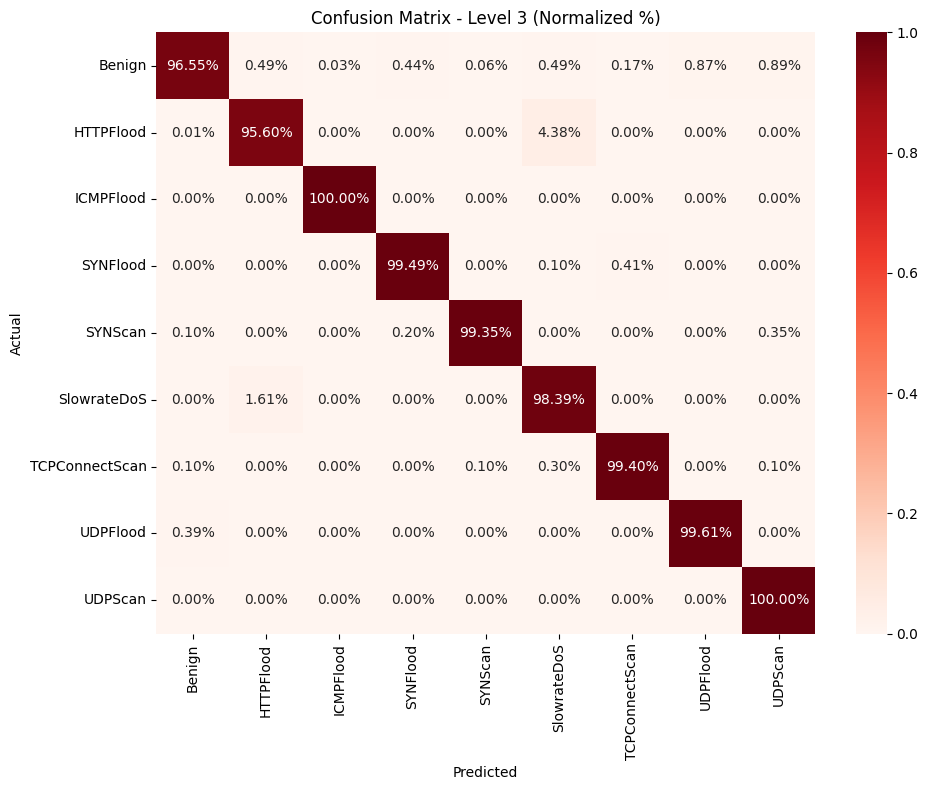

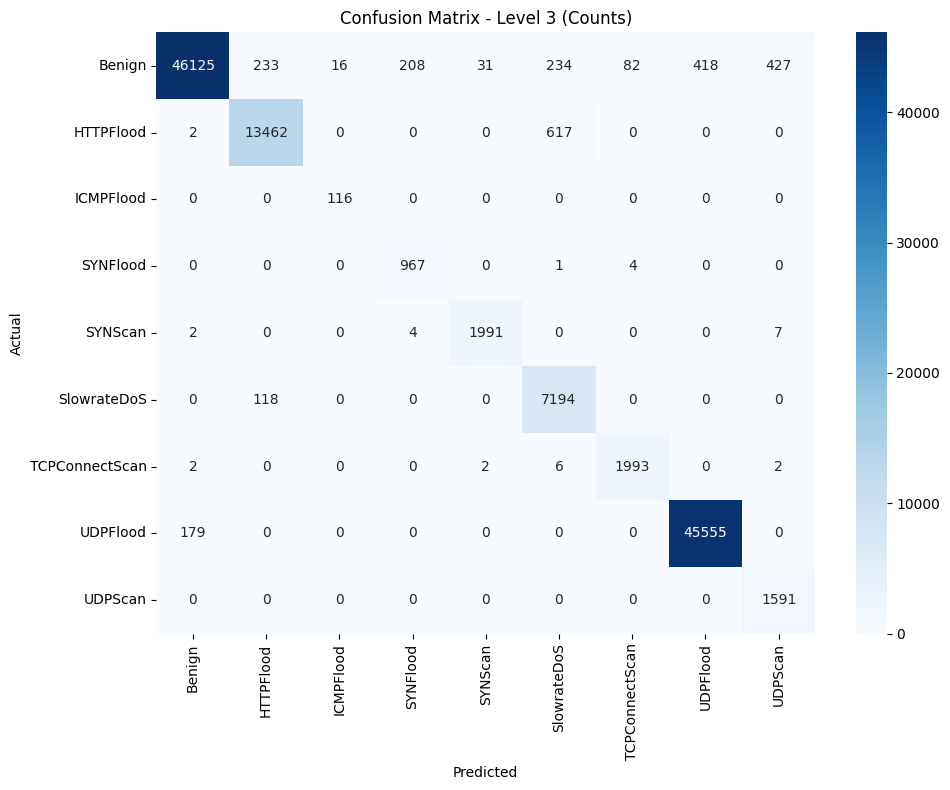

In [ ]:
print("\n Best Parameters (Level 3):", grid_search.best_params_)
print("Best Mean CV Accuracy:", grid_search.best_score_)

#  Evaluate best model
best_model_t = grid_search.best_estimator_
y_pred_t_raw = best_model_t.predict(X_test_t)

if y_pred_t_raw.ndim > 1:
    y_pred_t = np.argmax(y_pred_t_raw, axis=1)
else:
    y_pred_t = y_pred_t_raw

# Decode labels back to names
y_test_labels = label_encoder_type.inverse_transform(y_test_t)
y_pred_labels = label_encoder_type.inverse_transform(y_pred_t)

# Evaluation metrics
print("\n[LEVEL 3] Classification Report:")
print(classification_report(
    y_test_t, y_pred_t, target_names=label_encoder_type.classes_
))

#  Confusion Matrix (Raw & Normalized)
cm3 = confusion_matrix(y_test_labels, y_pred_labels, labels=label_encoder_type.classes_)
cm3_norm = cm3.astype('float') / cm3.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm3_norm, annot=True, fmt=".2%", cmap='Reds',
            xticklabels=label_encoder_type.classes_,
            yticklabels=label_encoder_type.classes_)
plt.title("Confusion Matrix - Level 3 (Normalized %)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cm3, annot=True, fmt="d", cmap='Blues',
            xticklabels=label_encoder_type.classes_,
            yticklabels=label_encoder_type.classes_)
plt.title("Confusion Matrix - Level 3 (Counts)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()